### Here comes an outline of what this code goes through:

The scope of the code is to solve for the optimal job search effort for people who have recently lost their job and are now on unemployment benefits. 

To do that we need to know what the value of being employed and unemployed is. The value of being unemployed and employed depends on the amount of assets that one holds and the reference income that the person has in the current period. Ones the value of being employed and unemployed in every period and for every asset level is found we can compute the maximal search effort in each period and for all asset levels. 

The optimal search effort is then used to compute the 'hazard rates' (meaning the rate of exit from unemployment benefits). Finally, we have to check how vulnerable our estimated hazard rates are to different assumptions and different benefit levels. 

#### 1. We find the steady state value of being either employed or unemployed by using value function iterations. 
#### 2. We create the income path and the reference income path
The agent uses the average of the last N periods to calculate its reference. 
#### 3. We use the reference path and the steady state value of employment to find the full value of employment in every period and for every asset level. 
We do that through backwards induction for the N periods of reference until the reference level is completely adjusted to having a wage income. In the N periods we evaluate at the gain level of the utility function.n
#### 4. We write up the search cost function

#### 5. We use the search cost function to backwards iterate to the optimal consumption level and search effort for all asset levels and for every period. 

------------------------------------------------------------------------------------------------

Now I haven't gotten any further, but what we have to do is: 
1. find the inverse of the optimal search cost function
2. Use that in combination with the relative values of employment and unemployment to find the hazard rates. 

------------------------------------------------------------------------------------------------

In [19]:
import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate  # Interpolation routines
from scipy.optimize import fsolve
#import model.py as model

#### 1. We find the SS values of employment and unemployment

It is a cake eating problem in the infinite horizon where the remaining cake grows with a given rate and an absolute factor too. 
$A' = (1+R)(A+w-c)$

And the the bellman equation is: 
$V(A) = max_{c \in A+w} ln (c) + \delta   V [(1+R)(A+w-c)]  $ \\

We can substitute $c = w + A + A' / (1+R) $ to get: \\

$V(A) = max_{0 \le A' \le A+w} ln (w + A + A' / (1+R)) + \delta   V ( A' )  $

Which is a problem solely with A, that is given and A´ which is the optimizing factor. 

In [ ]:
delta = 0.95
gamma = 0.4
eta = 1
k = 130
lmbda = 0.6

abar = [0, 20]
n_a = 50
n_c = 100

T1 = 12
T2 = 36
T3 = 48
T = 54
N = 5
b1=10
b2 = 8
b3 = 6 
welfare = 4
w = 15
R = 0.05

In [21]:
class ss_value:
    """Class to implement the stochastic cake eating model with discretized choice"""

    def __init__(self, delta, abar, n_a, n_c, w, R ):
        """Initializer"""
        self.delta = delta    # Discount factor
        self.abar = abar    # min and max savings
        self.n_a = n_a      # grid size for state variable
        self.n_c = n_c      # grid size for choice grid
        self.w = w          # wage
        self.R = R          # interest rate

        self.abar[0] = np.maximum(np.finfo(float).eps, self.abar[0])       # vælger den højeste værdi af minimumsværdien for abar og 'numerisk 0'. Vi vil ikke under numerisk 0.  
        # truncate lower bound at smallest positive float number
        # parameter dependent varibles
        self.a = np.linspace(self.abar[0], self.abar[1], n_a).reshape((n_a, 1))  # vi laver en vektor med state space fra 0 til abar og med det antal grid punkter vi vil have, n_a.  
        self.c = np.empty((n_a, n_c))  # starter consumption matrix med rækker for alle states og så et finere grid i kolonnerne for mulige consumption valg. 
        
        for i in range(n_a):            # fordi rækkerne er state-grids, så derfor skal vi have en række for hver state vi vil kigge på
            self.c[i, :] = np.linspace(self.abar[0], self.a[i]+self.w, n_c).reshape((1, n_c))  # vi laver hver række så den går fra '0' til den værdi i state grid, som vi kigger på. Altså, det vil svare til at vi kigger på alle mulige værdier for V(A=10)
                                                                                        # consumption choice bliver så lidt finere (det er kolonnerne her) og tager n_c grid points. 
                                                                                        # så hver række repræsenterer alle consumption choices givet en state value. 
        """" Det her er nok forkert. Vi skal have tilføjet + w i forbrugsmuligheden"""

        """Bellman operator, V0 is one-dim vector of values on state grid"""
    def bellman(self, V0, R):
        interp = interpolate.interp1d(self.a[:, 0], V0, bounds_error=False, fill_value="extrapolate")
        V = 0
        a1 = (self.a - self.c + self.w)*(1+R)       # vi laver a1 som funktion af hvad du forbruger     'a' er en 1 x n_a vektor
        V = interp(a1)                              # a1 bliver en n_a x n_c matrix     V svarer til de 100 forskellige niveauer af nytte i næste periode
                                                    # a1 er en funktion af c (de andre er faste), så får vi en værdi som ligger mellem grid points ved at interpolere.
                                                    # der er ikke noget med nytte. Er det med vilje fordi den endelige værdi af V altid være den som maksimerer nytten?
        matV1 = np.log(self.c) + self.delta * V      # c er en n_a x n_c vektor   a er en na x 1 vektor a1 bliver så en n_a x n_c matrix. Det gør V så også 
                                                    # så her lægges en n_a x n_c matrix til en n_a x n_c matrix, hvilket giver en n_a x n_c matrix.
        i_max = np.argmax(matV1, axis=1)            # vi kigger på den kolonne som giver den højeste nytte for hver række. n_a x 1 matrix
        # (column) index of optimal choices
        V1 = matV1[np.arange(self.n_a), i_max]          # Her går den igennem alle n_a rækker, og finder den kolonne i hver række, som giver den højeste værdi. 
        c1 = self.c[np.arange(self.n_a), i_max]         # den her viser, hvad det optimale forbrug så viste sig at være. 

        return V1, c1
    

Adding the value function iteration solver of the Bellman equation to the class. 

In [22]:
def vfi(self, maxiter=1000, tol=1e-10, callback=None):
    """Solves the model using VFI (successive approximations)"""
    tic = process_time()  # Start the stopwatch / counter

    V0 = np.log(self.a[:, 0])  # on first iteration assume consuming everything
    """eventuelt tilføj w i den initialle V0"""
    for iter in range(maxiter):
        V1, c1 = self.bellman(V0, self.R)
        if callback:
            callback(iter, self.a, V1, c1)  # callback for making plots
        if np.all(abs(V1 - V0) < tol):
            toc = process_time()  # Stop the stopwatch / counter
            print("Optimal consumption of assets solved in", iter, "iterations, using", round(toc - tic, 5), "seconds")
            break
        V0 = V1
    else:  # when i went up to maxiter
        print("No convergence: maximum number of iterations achieved!")
    return V1, c1

# Add the vfi_solve method to the cake_stochastic class
ss_value.solve = vfi

Here we export the SS values and associated consumption for both employment and unemployment for every asset level. 
It is the same code. The only difference is the wage in the final period, which is either a wage for a job or the welfare level of income. 

In [23]:
emp = ss_value(delta, abar, n_a, n_c, w, R)
Vss_emp, css_emp = emp.solve()

uemp = ss_value(delta, abar, n_a, n_c, w, R)
Vss_uemp, css_uemp = uemp.solve() 

Optimal consumption of assets solved in 468 iterations, using 0.22061 seconds
Optimal consumption of assets solved in 468 iterations, using 0.16688 seconds


Here the value function and the consumption for both being employed and unemployed for every asset level in steady state is plotted against each other 
- we can experiment with the plots a little bit. 

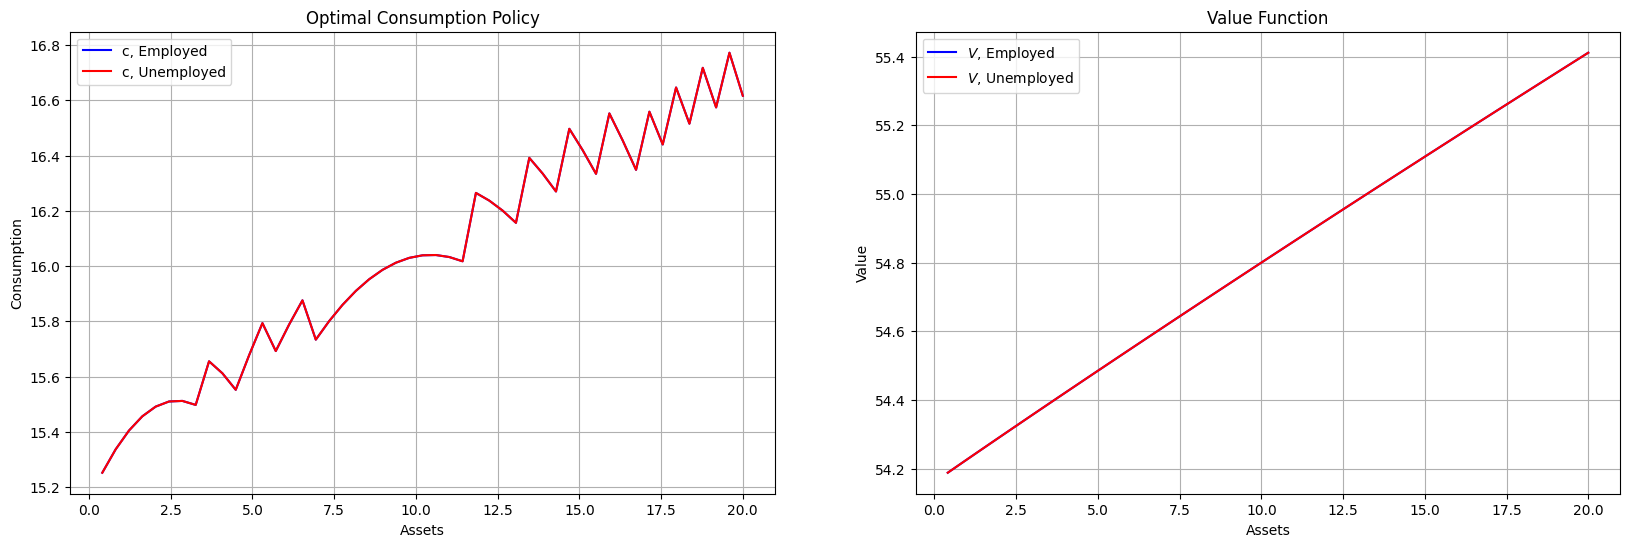

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
ax1.grid(True)
ax2.grid(True)
ax1.plot(emp.a[1:], css_emp[1:], color="b", label="c, Employed")
ax1.plot(emp.a[1:], css_uemp[1:], color="r", label="c, Unemployed")
ax1.set_xlabel("Assets")
ax1.set_ylabel("Consumption")
ax1.legend()
ax1.set_title("Optimal Consumption Policy")
ax2.plot(emp.a[1:], Vss_emp[1:], color="b", label="$V$, Employed")
ax2.plot(emp.a[1:], Vss_uemp[1:], color="r", label="$V$, Unemployed")
ax2.legend()
ax2.set_title("Value Function")
ax2.set_xlabel("Assets")
ax2.set_ylabel("Value")
plt.show()

Consumption burde jo ikke variere på den måde, men i stedet være roligt voksende funktioner. 

------------------------------------------------------------------------------------------------------------------------------------------------


#### 2. We find the income path and through that the reference path for getting a job in every period



In [25]:
class ref_inc_path():
    def __init__(self,w , b1, b2, b3, welfare, T1, T2, T3, T, N, eta ):
        self.w = w              # Løn
        self.b1 = b1            # højeste dagpengesats    
        self.b2 = b2            # næste dagepengesats
        self.b3 = b3            # laveste dagpengesats
        self.welfare = welfare  # 'kontanthjælp'
        self.T1 = T1            # periode til højeste dagpengesats
        self.T2 = T2            # periode til næste dagpengesats
        self.T3 = T3            # periode til laveste dagpengesats
        self.T = T              # periode til kontanthjælp
        self.N = N              # antal referenceperioder
        self.eta = eta          # det er for at kunne modificere løsningen til også at være ikke reference-dependent
        self.n_periods = self.T + 1 # Perioder i alt (job kan starte i periode 0 til T, og så er der en ekstra periode hvor man aldrig finder et job)
        self.never_emp = self.T + 1 # Periode hvor man aldrig finder et job. Vi laver en ekstra række i income path, som repræsenterer dette.
        

    def benefit_path_(self):                # vi laver income paths som en T, array med alle income levels for forskellige perioder
        '''
        Returns the benefit path given parameter values.
            Arguments:
                b1,b2,b3,welfare (all floats): values at distinct time windows during unemployment
                T1,T2,T3 (int): points in Unemp. spell when benefit levels change.
                T (int): Total number of periods
            Returns:
                benefits (array): Benefit path in unemployment
        '''
        benefits        = np.zeros(self.T)       # Laver en vektor med T, elementer. 
        benefits[0:self.T1]  = self.b1                # for de rigtige tidspunkter tilføjer den benefit levels. 
        benefits[self.T1:self.T2] = self.b2
        benefits[self.T2:self.T3] = self.b3
        benefits[self.T3:self.T]  = self.welfare

        return benefits

 
    def income_path_(self):                          
        '''Laver alle de mulige income paths. 
            En for alle tidspunkter hvorpå man finder et job, inklusiv muligheden for aldrig at finde et job
        '''
        benefits = self.benefit_path_()
        income_path = np.tile(benefits,(self.T+2,1))
        for j in np.arange(self.n_periods): 
            income_path[j,j:] = self.w

        income_path[self.never_emp, :] = self.welfare
        return income_path
    
    def ref_path_(self):             # the reference point is given as the arithmetic average of the income in the 5 periods leading up to the current one. 
        if self.eta > 0: 
            ref_path = np.zeros((self.T+2, self.T))
            income_path = self.income_path_()
        
            for t in np.arange(self.T): 
                if t == 0:
                    ref_path[:,t] = self.w         # vi antager at lønnen før og lønnen efter bistand er den samme. 

                if t > 0: 
                    N_pre = max(self.N - t, 0)  # vi sætter antal perioder med løn til at blive mindre, når man har været længere tid på DP. Indtil løn slet ikke indgår i referencen. 
                    '''Her modificerer jeg koden ned i kompleksitet, så vi ikke tager højde for eventuelle halve perioder. 
                    Da vi slet ikke har dem med. Se rdmodel.py, for den komplekse udgave'''
                    start = max(t-self.N, 0)
                    end = t
                        #Her laver vi summen / gennemsnittet. 
                        #Når t > 4 så betyder N_pre leddet ikke længere noget.
                    ref_path[:,t] = ( N_pre*self.w + np.sum(income_path[:,start:end], axis = 1, keepdims=False ) ) / self.N
            
                    # reference path tager gennemsnittet for de seneste fem perioder af indkomst for alle rækker i income path.
                    # så altid summen af de t-5 til t søjler i income path plus evt. led fra før dagpenge, hvis vi er i t < 5
                    # axis = 1 betyder at vi kigger på søjler keepdims = False betyder at vi kun returner en vektor med t værdier pr. række.
                    # så hver række i income path repræsenterer, hvornår man får job. Hver række i r repræsenterer den dertilhørende lønreference i alle perioder. 
        else: 
            ref_path = self.income_path_()    
            
        return ref_path
         
        
    def ref_path_long_(self):        # we create this to get the future values of ref-dependence when getting a job inside T-N last periods.
            
        add = np.zeros( (self.T+2, self.N)  )

        ref_path = self.ref_path_()
        ref_path_long = np.concatenate((ref_path, add), axis = 1)      # now we add N columns to the ref_path_
            
        income_path = self.income_path_()       # we add the income path to use it later

        for t in np.arange(self.T, self.T + self.N):
                
            start = min ( t - self.N , self.T)      # vi definerer start som den periode vi er i og minus de N perioder vi kigger tilbage. Vi går indtil sidste periode i income_path
            end = self.T                            # det her er måske overflødigt, fordi vi bare siger, at vi stopper ved enden. 

            ref_path_long[:,t] = (  np.sum(income_path[:,start:], axis = 1, keepdims=False     )   + (t-self.T)* self.w ) / self.N 
                                        # so what the code does is that it takes the sum of the last periods available in the income path
                                        # plus the sum of the periods not available and divides by N to get the average.                                  
        """ændrer den sidste række til blot at være den samme som den var før men 5 perioder mere, fordi han aldrig får et job. """
        # Række til dem der aldrig får et job
        ref_path_long[self.never_emp, self.T:] = self.welfare
        
        return ref_path_long
               

In [26]:
model = ref_inc_path(w, b1, b2, b3, welfare, T1, T2, T3, T, N, eta )
ref_path_long = model.ref_path_long_()
benefits = model.benefit_path_()
print(benefits)

#print(ref_path_long[54,50:])        # this is getting the job in period T + 1 that's why it doesn't converge. 
#print(ref_path_long.shape)


[10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.  8.  8.  8.  8.  8.  8.
  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.
  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  4.  4.  4.  4.  4.  4.]


------------------------------------------------------------------------------------------------------------------------------------------------

#### 3. We find the full value of getting a job for every asset level in every period

We solve the following maximization problem for every asset level in every period

$   V(A_t) = max _{0 \le A_{t+1} \le A_t } u \left(w+A_t + \frac{A_{t+1}}{1+R} \right) + \eta \left( u[w+A_t + \frac{A_{t+1}}{1+R}] - u[r_t]  \right)  + V(A_{t+1})    $ 




We call the steady state value function that we have already made in step 1

In [27]:
def employment_BI(Vss, ref_path, delta, eta, R, w, abar, T, N, n_a, n_c):
    abar[0] = np.maximum(np.finfo(float).eps, abar[0])              # vælger numerisk nul, så vi kan tage log. 
    a = np.linspace(abar[0], abar[1], n_a).reshape((n_a, 1))        # laver en n_a x 1 matrice med værdierne fra 0 til maks asset level. 

    c = np.empty((n_a, n_c))    # For hver state kan man vælge n_c forskellige niveauer af forbrug i perioden
    for i in range(n_a):        # vi kigger på alle rækkerne og tilføjer forbrugsmuligheder fra 0 og op til maks forbrug som er givet ved assets + løn.  
        c[i, :] = np.linspace(abar[0], (a[i]+w), n_c).reshape((1, n_c))     # Laver det om til en vektor med 1 række og n_c kolonner. 

    a1 = (a - c + w) * (1 + R)   # assets i næste periode. Det er en n_a x n_c matrix. 

    V_emp = np.zeros((T+1, n_a))   # placeholder variable for getting the job in period in period T with asset value a. 
    c_emp = np.zeros((T+1, n_a))   # associated optimal consumption, first period after job start, not really that relevant though...

    for j in np.arange(T+1):
        V0 = Vss   # steady state value from the value function iterations. 

        # step backward: n = N-1 (period closest to steady state) down to n = 0 (period job starts)
        for n in np.arange(N-1, -1, -1):
            interp = interpolate.interp1d(a[:, 0], V0, bounds_error=False, fill_value="extrapolate")    # here it always takes the latest V0 value, so a new one in every period. This is where the updated values get used. 
            V_next = interp(a1)     # V_next er jo altid den seneste værdi. Første del af loopet er så den 'interpolerede' værdi fra v_ss af givne asset levels mellem grids. 

            matV1 = np.log(c) + eta * (np.log(c) - np.log(ref_path[j, j+n])) + delta * V_next    # nytteværdi for givet 'j' jobtidspunkt for n-perioder efter job er fundet. 
                                                            # og så fordi at c er defineret som alle forbrugsmuligheder med forskellige asset levels overholdet det budget begrænsningen. 
            i_max = np.argmax(matV1, axis=1)                # hvordan overholder vi budgetbegrænsningen i næste periode? 
            V0 = matV1[np.arange(n_a), i_max]               # her opdateres værdierne givet det optimale forbrugsval. Det bliver så genbrugt til næste periode. 
            c_current = c[np.arange(n_a), i_max]

        V_emp[j, :] = V_emp[j,:] + V0
        c_emp[j, :] = c_current

    V_emp = V_emp.transpose()
    c_emp = c_emp.transpose()
    return V_emp, c_emp

Her får vi værdierne. c_out er lidt ligemeget, fordi det er den endelige c-værdi, hvilket vi egentlig ikke skal bruge. Altså, vi tracker slet ikke på den her måde den rigtige consumption path, men kun den sidste værdi. Vi skal heller ikke rigtigt bruge den, men hvis vi vil, så har claude lavet et udkast til kode for det, som ligger i VFI asset. 

We output the values of employment for every period and every asset level.

In [28]:
V_emp, c_emp = employment_BI(Vss_emp , ref_path_long, delta, eta, R, w, abar, T, N, n_a, n_c)

print(V_emp[:,54])       # kolonnerne er asset levels
                        # rækkerne er tidspunkter at få jobbet på
                        
                        # det kan vi se her fordi at der sket et rigtig stort spring fra asset level 0 til 1. Ikke længere faktisk, fordi der nu kommer en løn. 
                        # Hvilket kommer af nytten fra logaritmen til approksimativt 0 er næsten minus uendelig. 

print(V_emp[49,:])       # vi kan også se det ved det her print, hvor nogle af værdierne er ens fordi personerne når at tilpasse sig de nye lavere niveauer af indkomst. 
                        
# vi kan også bare se det ved at kigge på shape, hvor der er 50 asset levels og 54+1 tidsperioder. 
print(V_emp.shape)

[57.27223405 57.32611577 57.37971289 57.43306503 57.48616903 57.53894434
 57.59127205 57.64339138 57.69522048 57.74681305 57.79812459 57.84901829
 57.89967504 57.95007105 58.00019469 58.05004144 58.09963962 58.14888723
 58.19788534 58.2466527  58.29518261 58.34345454 58.39142738 58.43914193
 58.48668778 58.53397531 58.58091037 58.62763409 58.67417119 58.72045338
 58.76649195 58.81236763 58.85787613 58.90323057 58.94839715 58.99325811
 59.03787649 59.0822468  59.12657406 59.17048585 59.21440542 59.25799602
 59.30134347 59.34449664 59.38749225 59.43024864 59.47279561 59.51521642
 59.55732076 59.59938452]
[56.4881545  56.80030455 57.07523587 57.30355769 57.47322987 57.56854005
 57.56854005 57.56854005 57.56854005 57.56854005 57.56854005 57.56854005
 57.56854005 57.72555309 57.86398524 57.97926387 58.06537295 58.11416311
 58.11416311 58.11416311 58.11416311 58.11416311 58.11416311 58.11416311
 58.11416311 58.11416311 58.11416311 58.11416311 58.11416311 58.11416311
 58.11416311 58.11416311 

------------------------------------------------------------------------------------------------------------------------------------------------

#### 4. We write up the search cost function.

The optimal search effort is found through the FOC of the value function for unemployment wrt. s. This leaves us with a function showing the marginal change in the optimal search effort for changes in the asset levels. 

$
\text{FOC:} \frac{\partial V^U_t(A_t)}{\partial s_t}=0 \\
    \leftrightarrow 
    c'(s_t^*(A_{t+1}) = \delta [V^E_{t+1|t+1}(A_{t+1})-V^U_{t+1}(A_{t+1})] 
$

Here the sanity check is that the marginal search effort should be decreasing in A. Which it does because we have diminishing marginal return to income and since the income level when unemployed is lowest then: 

$V^U (A+1) - V^U(A) > V^E(A+1)-V^E(A) $

From the first order condition we can isolate s by taken the inverse of the derivative of the search cost function. 

$c_s = \frac{ks^{1+\gamma}}{1+\gamma}$ then $c'_s = ks^\gamma$ and the inverse is given by: 

$c'(s) = ks^\gamma \\
 \leftrightarrow s = \left( \frac{c'}{k} \right)^{1/\gamma } = 
 c'^{-1}(\cdot) =
\mathcal{C}(\cdot)    $ 

So we must 

$s^*_t = \mathcal{C}(\delta [V^E_{t+1|t+1}(A_{t+1})-V^U_{t+1}(A_{t+1})]) = \left( \frac{\delta }{k} [V^E_{t+1|t+1}(A_{t+1})-V^U_{t+1}(A_{t+1})] \right)^{1/\gamma}$ 




In [29]:
# Search Cost: here arguments are scale parameter (k), level of search effort (s) and curvature parameter (gamma)
def cost(s,k,gamma):
    '''
    Returns the value of the search cost function.
        Arguments:
            s (float): Search effort
            k (float): Constant parameter in the search cost function
            gamma (float): Shape/elasticity parameter in the search cost function.
        Returns:
            cost(args) (float): Value of the search cost function.
    '''
    return k*s**(1+gamma)/(1+gamma)


In [30]:
def cost_prime_inverse(V_emp,V_uemp,k,gamma,delta):
    '''
    Returns the value of the inverse of the first derivative of the search cost function.
        Arguments:
            k (float): Scaling parameter in the search cost function
            gamma (float): Shape/elasticity parameter in the search cost function.
            delta (float): Intertemporal discount factor
            valSearch (float): Net value of job search while unemployed
        Returns:
            search (float): Value of the inverse of the first derivative of the search cost function.
    '''
    # Since s is a probability and within [0,1], we set boundaries at 0 and 1, to make sure, it does not return a value outside this interval
    #search = min(1,max(delta/k*(V_emp-V_uemp),0))**(1/gamma)
    # np.clip will clip values outside the interval to the interval edges.
    # here we use the interval between 0 and 1, and clip the value of delta/k*(V_emp-V_uemp) to be within this interval.
    search = np.clip(delta/k*(V_emp-V_uemp), 0, 1)**(1/gamma)

    # search = 0
    return search

------------------------------------------------------------------------------------------------------------------------------------------------

#### 5. We use the search cost function to backwards iterate to the optimal consumption level and search effort for all asset levels and for every period.

We do that through approximately the same function, but adjusted to being in the 'loss' section of the gain-loss part of the value function and adjusted to the decreasing income throughout the benefit path. 

I 'def_solve_single_type_models' i koden fra harvard, så har de det, men bare ikke får asset levels. Så det er grundlæggende 'blot' at udvide med hvert asset level. Alle de nødvendige komponenter har vi allerede lavet nu. 

In [31]:

S = np.zeros((n_a, T))
V_U = np.zeros((n_a, T))
S[:, T-1]= cost_prime_inverse(Vss_emp, Vss_uemp, k, gamma, delta)
V_U[:, T-1] = (np.log(benefits[-1]) - cost(S[:, T-1], k, gamma) + delta*(S[:, T-1]*Vss_emp + (1-S[:, T-1])*Vss_uemp))

for t in np.arange(T-2, -1, -1):
    S[:, t] = cost_prime_inverse(V_emp[:, t+1], V_U[:, t+1], k, gamma, delta)
    V_U[:, t] = (np.log(benefits[t]) - cost(S[:, t], k, gamma) + delta*(S[:, t]*V_emp[:, t+1] + (1-S[:, t])*V_U[:, t+1]))
    


In [32]:
gap = delta / k * (V_emp[:, -1] - V_U[:, -1])

print(gap)
print(S[:, -2])

[0.21056683 0.21191041 0.21324665 0.21457617 0.21589804 0.21720792
 0.21849975 0.21978473 0.22105929 0.22232632 0.22358186 0.22482131
 0.22605107 0.22727202 0.22848165 0.2296805  0.23087039 0.2320461
 0.23321156 0.23436807 0.2355154  0.23665257 0.23777759 0.23889234
 0.24000106 0.2410995  0.24218325 0.2432592  0.24432883 0.24538681
 0.24643542 0.24747774 0.24850521 0.24952702 0.25054071 0.2515423
 0.25253536 0.25351552 0.25449732 0.25546091 0.25642521 0.25737746
 0.2583175  0.25925173 0.26017927 0.26109698 0.26200772 0.26291158
 0.2638054  0.26469468]
[0.02034581 0.02067192 0.02099934 0.02132818 0.02165817 0.02198817
 0.02231656 0.02264612 0.02297587 0.02330651 0.02363695 0.0239659
 0.02429497 0.02462436 0.02495332 0.02528193 0.02561065 0.02593795
 0.02626486 0.0265917  0.02691834 0.02724445 0.0275694  0.02789366
 0.02821843 0.02854242 0.02886425 0.02918591 0.0295078  0.02982827
 0.03014795 0.03046775 0.03078497 0.0311024  0.03141925 0.0317342
 0.03204834 0.03236021 0.03267443 0.032984

In [33]:
print("V_emp terminal:")
print(V_emp[:, -1])

print("Vss_emp:")
print(Vss_emp)

print("difference:")
print(V_emp[:, -1] - Vss_emp)

V_emp terminal:
[57.27223405 57.32611577 57.37971289 57.43306503 57.48616903 57.53894434
 57.59127205 57.64339138 57.69522048 57.74681305 57.79812459 57.84901829
 57.89967504 57.95007105 58.00019469 58.05004144 58.09963962 58.14888723
 58.19788534 58.2466527  58.29518261 58.34345454 58.39142738 58.43914193
 58.48668778 58.53397531 58.58091037 58.62763409 58.67417119 58.72045338
 58.76649195 58.81236763 58.85787613 58.90323057 58.94839715 58.99325811
 59.03787649 59.0822468  59.12657406 59.17048585 59.21440542 59.25799602
 59.30134347 59.34449664 59.38749225 59.43024864 59.47279561 59.51521642
 59.55732076 59.59938452]
Vss_emp:
[54.16100402 54.18794688 54.21475298 54.24145005 54.26805554 54.29458063
 54.32103475 54.34742113 54.37373294 54.39996262 54.42615116 54.45225661
 54.47832718 54.50431841 54.53027411 54.55617707 54.58201683 54.60780182
 54.63355158 54.65925649 54.68491502 54.71052712 54.73609375 54.76161591
 54.78709424 54.81252849 54.83791705 54.86325618 54.888539   54.91381159


#### Test om Value of employment er voksende i de sidste perioder

In [34]:
for j in [49, 50, 51, 52, 53, 54]:
    diff = V_emp[:, j] - Vss_emp

    print(
        j,
        "min diff =", diff.min(),
        "max diff =", diff.max()
    )

49 min diff = 2.492813326782162 max diff = 3.569840838770048
50 min diff = 2.691588633560073 max diff = 3.768616145547952
51 min diff = 2.8695141303658858 max diff = 3.946541642353772
52 min diff = 3.015919846487783 max diff = 4.092947358475669
53 min diff = 3.1112300262921053 max diff = 4.188257538279991
54 min diff = 3.1112300262921053 max diff = 4.188257538279991


#### Test om maximale og minimale search effort er faldende i de sidste perioder

In [35]:
for t in range(T-6, T):
    print(
        t,
        "S min =", S[:, t].min(),
        "S max =", S[:, t].max()
    )

48 S min = 0.0935952421605254 S max = 0.12899880329305746
49 S min = 0.07386496722570819 S max = 0.10610371799576916
50 S min = 0.054244108653437886 S max = 0.08188778074474466
51 S min = 0.03598738855067186 S max = 0.05794541400157704
52 S min = 0.02034580560208496 S max = 0.036046493271927826
53 S min = 0.0 S max = 0.0


#### Test om forskellen mellem Sidste periodes V_emp og Steady state af V_emp er den samme (numerisk tæt på nul) når vi ikke har reference dependence

In [36]:
eta = 0

V_emp_test, _ = employment_BI(
    Vss=Vss_emp,
    ref_path=ref_path_long,
    w=w,
    R=R,
    delta=delta,
    eta=eta,
    T=54,
    N=5,
    n_a=n_a,
    n_c=n_c,
    abar=abar.copy()
)

print(np.max(np.abs(V_emp_test[:, -1] - Vss_emp)))

4.2366821162431734e-10


In [37]:
V_U[49,:]

array([49.38681674, 49.40804166, 49.40945949, 49.39034369, 49.35156329,
       49.29651885, 49.23230224, 49.15721344, 49.06917233, 48.96560776,
       48.84330329, 48.69817726, 48.5249602 , 48.56287098, 48.5884567 ,
       48.60211509, 48.60540488, 48.6017153 , 48.59721333, 48.59171897,
       48.58501172, 48.57682129, 48.56681589, 48.55458758, 48.53963394,
       48.52133469, 48.49892194, 48.47144175, 48.43770412, 48.3962168 ,
       48.34509663, 48.28194833, 48.20369554, 48.10633904, 47.98460085,
       47.83138161, 47.63689838, 47.71750791, 47.78527475, 47.84122387,
       47.88873144, 47.9353416 , 47.99580857, 48.07396197, 48.17450134,
       48.30307684, 48.46630442, 48.67167143, 48.92728634, 49.70112409,
       50.59754313, 51.62028677, 52.76633791, 54.026865  ])

In [38]:
V_U[10,:]

array([48.2502776 , 48.25402041, 48.24027055, 48.20820492, 48.15834772,
       48.09333801, 48.01885924, 47.93333461, 47.83485927, 47.72110918,
       47.58921566, 47.4355893 , 47.25566583, 47.28795862, 47.30909188,
       47.31946623, 47.32049733, 47.3151684 , 47.30879754, 47.30117901,
       47.29206558, 47.2811598 , 47.26810324, 47.25246319, 47.23371614,
       47.21122713, 47.18422353, 47.15176171, 47.11268397, 47.06556222,
       47.00862326, 46.93964776, 46.8558311 , 46.75358699, 46.62826294,
       46.47371452, 46.28164444, 46.36741751, 46.44378714, 46.51252459,
       46.5776786 , 46.64708035, 46.73472229, 46.84487307, 46.98250866,
       47.15327679, 47.36337465, 47.61931609, 47.92757827, 48.7460785 ,
       49.67406132, 50.71133499, 51.85307425, 53.09113797])

In [ ]:
def SolveModel(delta, abar, n_a, n_c, R, k, gamma, eta, T1, T2, T3, T, N, b1, b2, b3, welfare, w ):
    '''
    Returns the value of the optimal search effort.
        Arguments:
            
            k (float): Scaling parameter in the search cost function
            gamma (float): Shape/elasticity parameter in the search cost function.
            delta (float): Intertemporal discount factor
            valSearch (float): Net value of job search while unemployed
        Returns:
            search (float): Value of the optimal search effort.
    '''
    #Steady State Values for employment and unemployment
    emp = ss_value(delta, abar, n_a, n_c, w, R)
    Vss_emp, css_emp = emp.solve()
    uemp = ss_value(delta, abar, n_a, n_c, w, R)
    Vss_uemp, css_uemp = uemp.solve()

    # Income paths
    model = ref_inc_path(w, b1, b2, b3, welfare, T1, T2, T3, T, N, eta )
    ref_path_long = model.ref_path_long_()
    benefits = model.benefit_path_()

    #Find full value of employment and unemployment for all asset levels and all periods
    V_emp, c_emp = employment_BI(Vss_emp , ref_path_long, delta, eta, R, w, abar, T, N, n_a, n_c)

    

    S = np.zeros((n_a, T))
    V_U = np.zeros((n_a, T))
    S[:, T-1]= cost_prime_inverse(Vss_emp, Vss_uemp, k, gamma, delta)
    V_U[:, T-1] = (np.log(benefits[-1]) - cost(S[:, T-1], k, gamma) + delta*(S[:, T-1]*Vss_emp + (1-S[:, T-1])*Vss_uemp))

    for t in np.arange(T-2, -1, -1):
        S[:, t] = cost_prime_inverse(V_emp[:, t+1], V_U[:, t+1], k, gamma, delta)
        V_U[:, t] = (np.log(benefits[t]) - cost(S[:, t], k, gamma) + delta*(S[:, t]*V_emp[:, t+1] + (1-S[:, t])*V_U[:, t+1]))

    return S, V_U, V_emp, c_emp, Vss_emp, Vss_uemp

In [17]:
S, V_U, V_emp, c_emp, Vss_emp, Vss_uemp = SolveModel(delta, abar, n_a, n_c, R, k, gamma, eta, T1, T2, T3, T, N, b1, b2, b3, welfare, w )

Optimal consumption of assets solved in 468 iterations, using 0.23516 seconds
Optimal consumption of assets solved in 468 iterations, using 0.14074 seconds


In [39]:
V_U[10,:]

array([48.2502776 , 48.25402041, 48.24027055, 48.20820492, 48.15834772,
       48.09333801, 48.01885924, 47.93333461, 47.83485927, 47.72110918,
       47.58921566, 47.4355893 , 47.25566583, 47.28795862, 47.30909188,
       47.31946623, 47.32049733, 47.3151684 , 47.30879754, 47.30117901,
       47.29206558, 47.2811598 , 47.26810324, 47.25246319, 47.23371614,
       47.21122713, 47.18422353, 47.15176171, 47.11268397, 47.06556222,
       47.00862326, 46.93964776, 46.8558311 , 46.75358699, 46.62826294,
       46.47371452, 46.28164444, 46.36741751, 46.44378714, 46.51252459,
       46.5776786 , 46.64708035, 46.73472229, 46.84487307, 46.98250866,
       47.15327679, 47.36337465, 47.61931609, 47.92757827, 48.7460785 ,
       49.67406132, 50.71133499, 51.85307425, 53.09113797])

In [ ]:
def unemployment_BI(Vss, ref_path, delta, eta, lmbda , R, benefits, abar, T, N, n_a, n_c):
    
    abar[0] = np.maximum(np.finfo(float).eps, abar[0])              # vælger numerisk nul, så vi kan tage log. 
    a = np.linspace(abar[0], abar[1], n_a).reshape((n_a, 1))        # laver en n_a x 1 matrice med værdierne fra 0 til maks asset level. 

    c = np.empty((n_a, n_c))    # For hver state kan man vælge n_c forskellige niveauer af forbrug i perioden
    for i in range(n_a):        # vi kigger på alle rækkerne og tilføjer forbrugsmuligheder fra 0 og op til maks forbrug som er givet ved assets + løn.  
        c[i, :] = np.linspace(abar[0], (a[i]+w), n_c).reshape((1, n_c))     # Laver det om til en vektor med 1 række og n_c kolonner. 

    a1 = (a - c + w) * (1 + R)   # assets i næste periode

    V_unemp = np.zeros((T+1, n_a))   # placeholder variable for getting the job in period in period T with asset value a. 
    c_unemp = np.zeros((T+1, n_a))   # associated optimal consumption, first period after job start, not really that relevant though...

    for j in np.arange(T+1):
        V0 = Vss   # steady state value from the value function iterations. 

        # step backward: n = N-1 (period closest to steady state) down to n = 0 (period job starts)
        for n in np.arange(N-1, -1, -1):
            interp = interpolate.interp1d(a[:, 0], V0, bounds_error=False, fill_value="extrapolate")    # here it always takes the latest V0 value, so a new one in every period. This is where the updated values get used. 
            V_next = interp(a1)     # V_next er jo altid den seneste værdi. Første del af loopet er så den 'interpolerede' værdi fra v_ss af givne asset levels mellem grids. 

            matV1 = np.log(c) + eta * lmbda * (np.log(c) - np.log(ref_path[-1, j+n])) + delta * V_next    # vi kigger kun på den nederste række i ref_path, fordi de aldrig får jobbet, men vi kigger stadig på den j'te periode og +n perioder frem. 
                                                            # og så fordi at c er defineret som alle forbrugsmuligheder med forskellige asset levels overholdet det budget begrænsningen. 
            i_max = np.argmax(matV1, axis=1)                # hvordan overholder vi budgetbegrænsningen i næste periode? 
            V0 = matV1[np.arange(n_a), i_max]               # her opdateres værdierne givet det optimale forbrugsval. Det bliver så genbrugt til næste periode. 
            c_current = c[np.arange(n_a), i_max]
    
        V_unemp[j, :] = V0
        c_unemp[j, :] = c_current
    
    return V_unemp, c_unemp

In [ ]:
test = np.array([1,2,3,4,5,6])
print(test[-1])

In [ ]:

# hvad skal vi ændre
# 1. lønnen, vi skal tilføje benefit path som løn
# 2. vi skal ændre initialle V0 til at være den steady state value for unemployed.
# 3. vi skal ændre ref_path til kun at være ref_path i den periode, hvor man aldrig får jobbet. Altså række T+1. 
